In [53]:
# Import essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [54]:
# Set aesthetics for visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 8)


In [55]:
# Load sample dataset (Titanic dataset)
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)


In [56]:
# Display first few rows of the dataset
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [57]:
# Check dataset information
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [58]:
# Generate basic summary statistics
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [59]:
# Count missing values in each column
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [60]:
# Check unique values in categorical columns
for col in df.select_dtypes(include=['object']).columns:
    print(f"\nUnique values in {col}:")
    print(df[col].value_counts())



Unique values in Name:
Name
Dooley, Mr. Patrick                                    1
Braund, Mr. Owen Harris                                1
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    1
Heikkinen, Miss. Laina                                 1
Futrelle, Mrs. Jacques Heath (Lily May Peel)           1
                                                      ..
Hewlett, Mrs. (Mary D Kingcome)                        1
Vestrom, Miss. Hulda Amanda Adolfina                   1
Andersson, Mr. Anders Johan                            1
Saundercock, Mr. William Henry                         1
Bonnell, Miss. Elizabeth                               1
Name: count, Length: 891, dtype: int64

Unique values in Sex:
Sex
male      577
female    314
Name: count, dtype: int64

Unique values in Ticket:
Ticket
347082              7
1601                7
CA. 2343            7
3101295             6
CA 2144             6
                   ..
PC 17590            1
17463               1
330877         

In [61]:
# Univariate Analysis - Summary Statistics
# Calculate statistical measures including skewness for numerical variables
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
stats_df = pd.DataFrame({
    'Mean': df[num_cols].mean(),
    'Median': df[num_cols].median(),
    'Std Dev': df[num_cols].std(),
    'Skewness': df[num_cols].skew(),
    'Kurtosis': df[num_cols].kurt()
})
stats_df.round(2)


,Mean,Median,Std Dev,Skewness,Kurtosis
PassengerId,446.00,446.00,257.35,0.00,-1.20
Survived,0.38,0.00,0.49,0.48,-1.78
Pclass,2.31,3.00,0.84,-0.63,-1.28
Age,29.70,28.00,14.53,0.39,0.18
SibSp,0.52,0.00,1.10,3.70,17.88
Parch,0.38,0.00,0.81,2.75,9.78
Fare,32.20,14.45,49.69,4.79,33.40


In [62]:
# Univariate Analysis - Visualizations
# Distribution of age
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

Text(0.5, 0, 'Age')

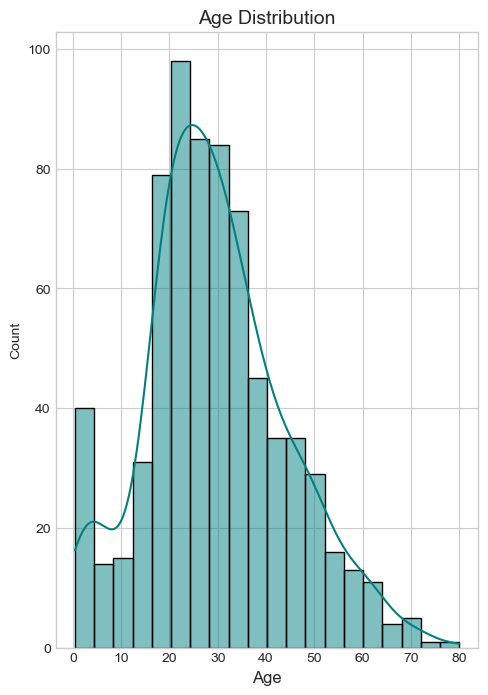

In [63]:
# Histogram with KDE
plt.subplot(1, 2, 1)
sns.histplot(df['Age'].dropna(), kde=True, color='teal')
plt.title('Age Distribution', fontsize=14)
plt.xlabel('Age', fontsize=12)

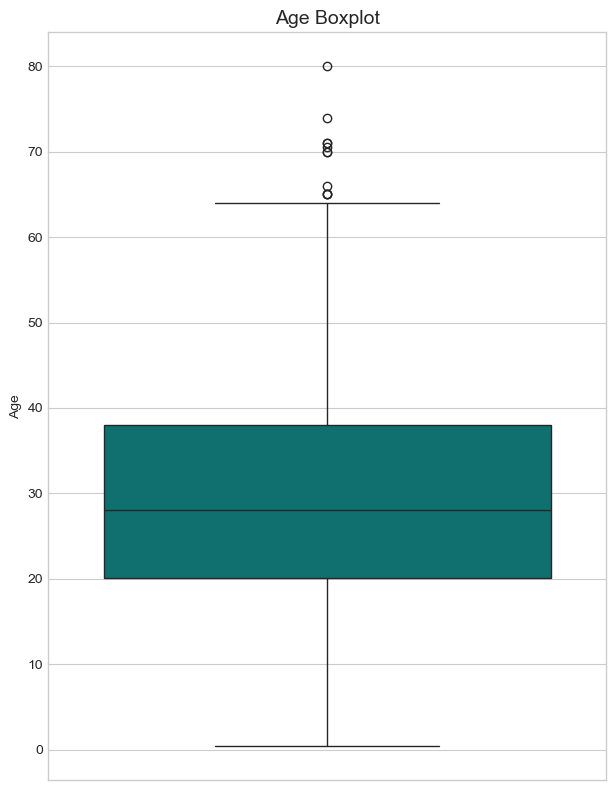

In [64]:
# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(y=df['Age'].dropna(), color='teal')
plt.title('Age Boxplot', fontsize=14)
plt.tight_layout()
plt.show()

In [65]:
# Distribution of fare
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

Text(0.5, 0, 'Fare')

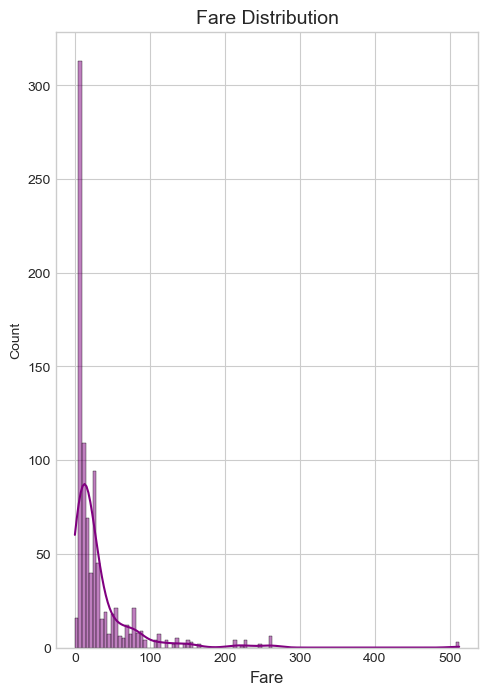

In [66]:
# Histogram with KDE
plt.subplot(1, 2, 1)
sns.histplot(df['Fare'], kde=True, color='purple')
plt.title('Fare Distribution', fontsize=14)
plt.xlabel('Fare', fontsize=12)

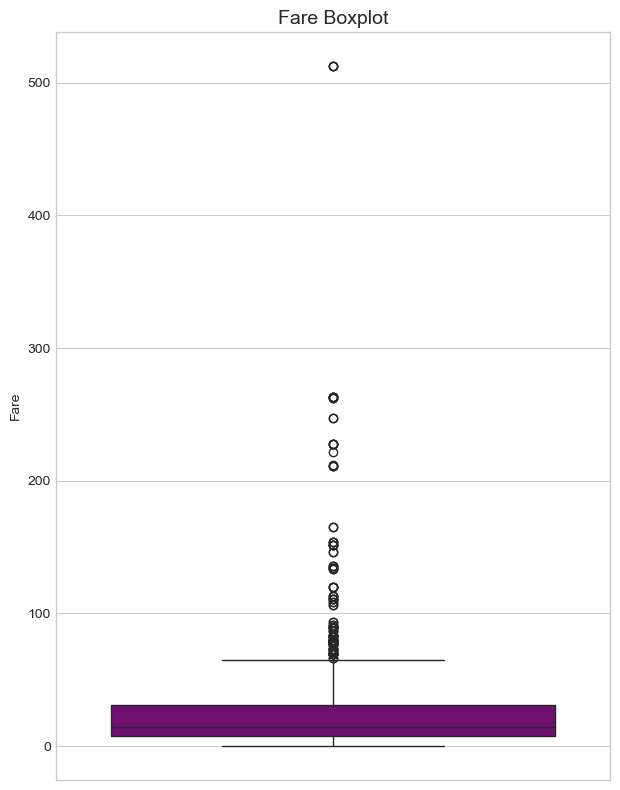

In [67]:
# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(y=df['Fare'], color='purple')
plt.title('Fare Boxplot', fontsize=14)
plt.tight_layout()
plt.show()

In [68]:
# Categorical value counts with visualization
plt.figure(figsize=(15, 12))

<Figure size 1500x1200 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

Text(0.5, 1.0, 'Passenger Class Distribution')

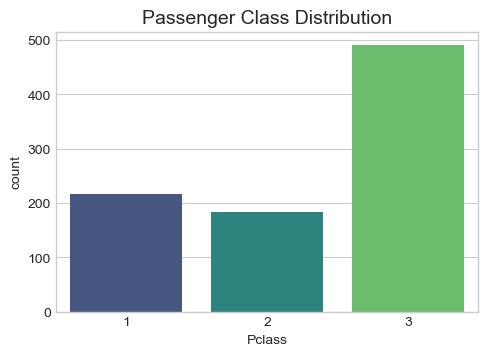

In [69]:
# Passenger class distribution
plt.subplot(2, 2, 1)
sns.countplot(x='Pclass', data=df, palette='viridis')
plt.title('Passenger Class Distribution', fontsize=14)

Text(0.5, 1.0, 'Gender Distribution')

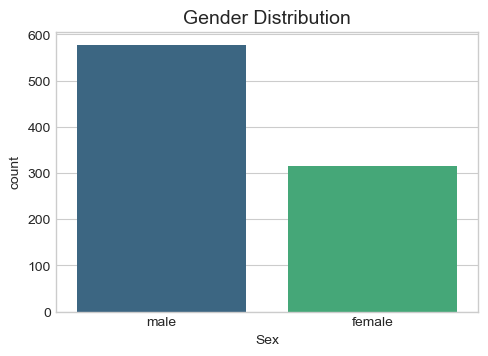

In [70]:
# Gender distribution
plt.subplot(2, 2, 2)
sns.countplot(x='Sex', data=df, palette='viridis')
plt.title('Gender Distribution', fontsize=14)

Text(0.5, 1.0, 'Port of Embarkation')

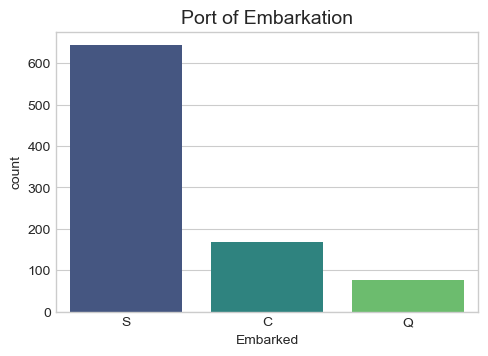

In [71]:
# Embarked distribution
plt.subplot(2, 2, 3)
sns.countplot(x='Embarked', data=df, palette='viridis')
plt.title('Port of Embarkation', fontsize=14)

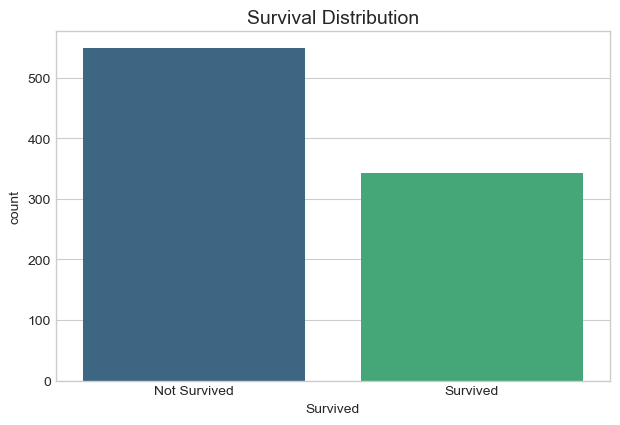

In [72]:
# Survival distribution
plt.subplot(2, 2, 4)
sns.countplot(x='Survived', data=df, palette='viridis')
plt.title('Survival Distribution', fontsize=14)
plt.xticks([0, 1], ['Not Survived', 'Survived'])

plt.tight_layout()
plt.show()

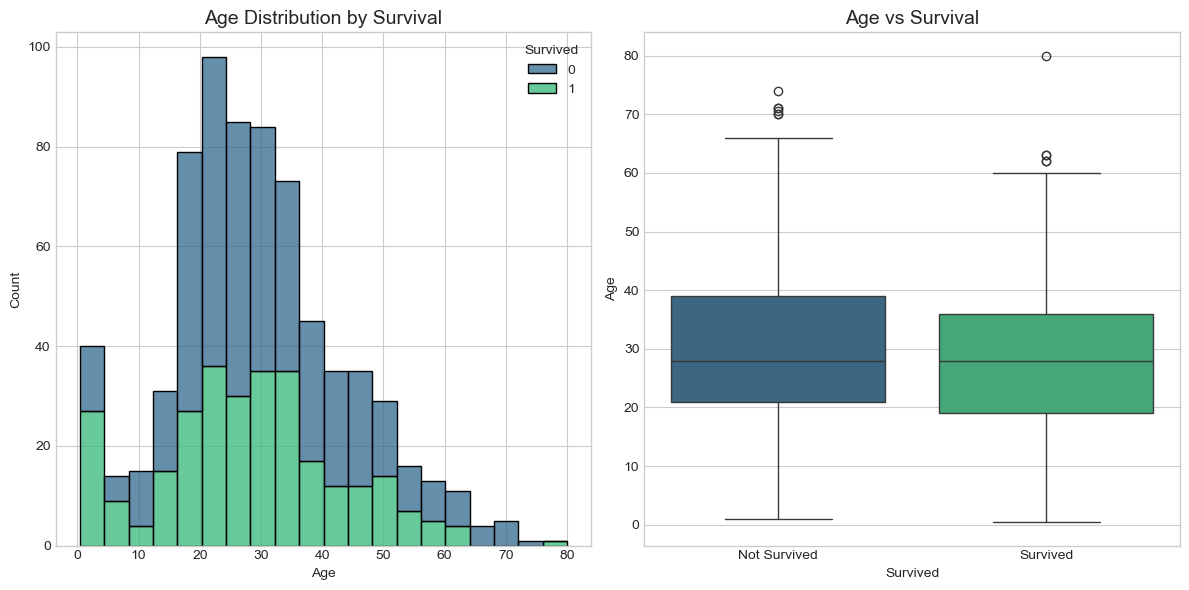

In [73]:
# Bivariate Analysis
# Age distribution by survival status
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x='Age', hue='Survived', multiple='stack', palette='viridis')
plt.title('Age Distribution by Survival', fontsize=14)

plt.subplot(1, 2, 2)
sns.boxplot(x='Survived', y='Age', data=df, palette='viridis')
plt.title('Age vs Survival', fontsize=14)
plt.xticks([0, 1], ['Not Survived', 'Survived'])

plt.tight_layout()
plt.show()

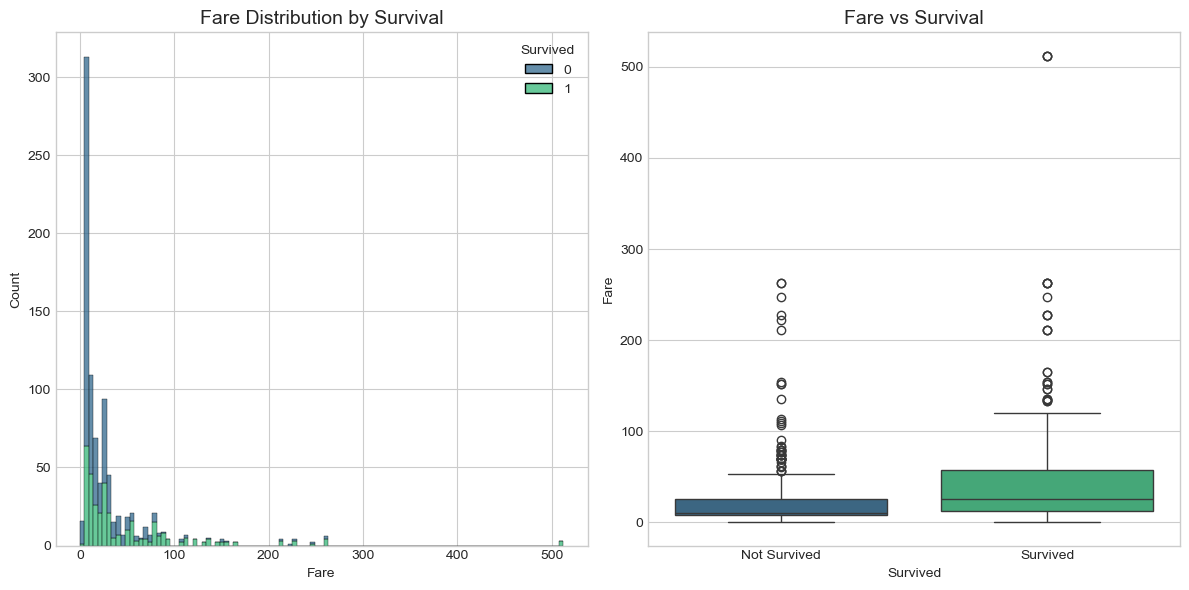

In [74]:
# Fare distribution by survival status
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x='Fare', hue='Survived', multiple='stack', palette='viridis')
plt.title('Fare Distribution by Survival', fontsize=14)

plt.subplot(1, 2, 2)
sns.boxplot(x='Survived', y='Fare', data=df, palette='viridis')
plt.title('Fare vs Survival', fontsize=14)
plt.xticks([0, 1], ['Not Survived', 'Survived'])

plt.tight_layout()
plt.show()

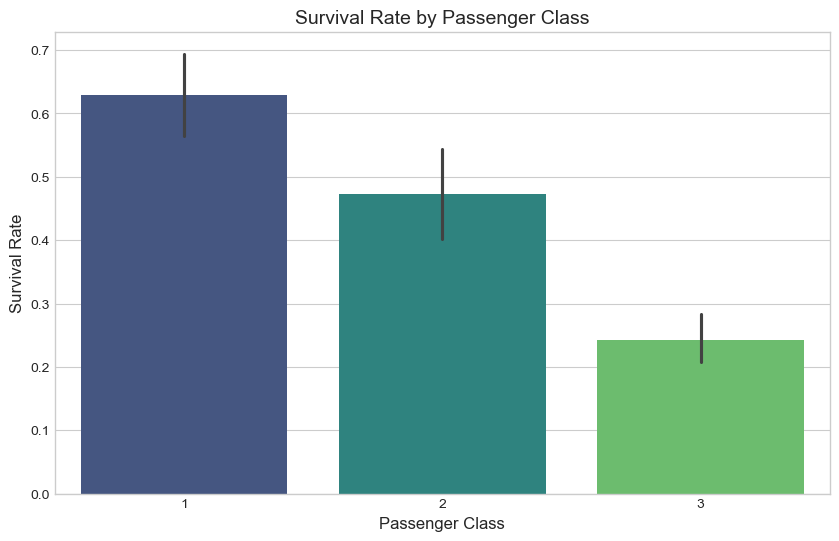

In [75]:
# Survival rate by Passenger Class
plt.figure(figsize=(10, 6))
sns.barplot(x='Pclass', y='Survived', data=df, estimator=np.mean, palette='viridis')
plt.title('Survival Rate by Passenger Class', fontsize=14)
plt.xlabel('Passenger Class', fontsize=12)
plt.ylabel('Survival Rate', fontsize=12)
plt.show()

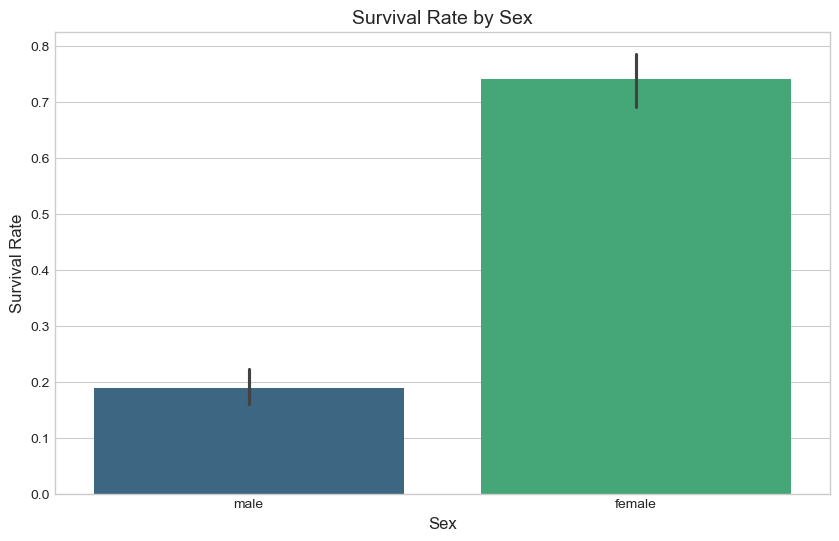

In [76]:
# Survival rate by Sex
plt.figure(figsize=(10, 6))
sns.barplot(x='Sex', y='Survived', data=df, estimator=np.mean, palette='viridis')
plt.title('Survival Rate by Sex', fontsize=14)
plt.xlabel('Sex', fontsize=12)
plt.ylabel('Survival Rate', fontsize=12)
plt.show()

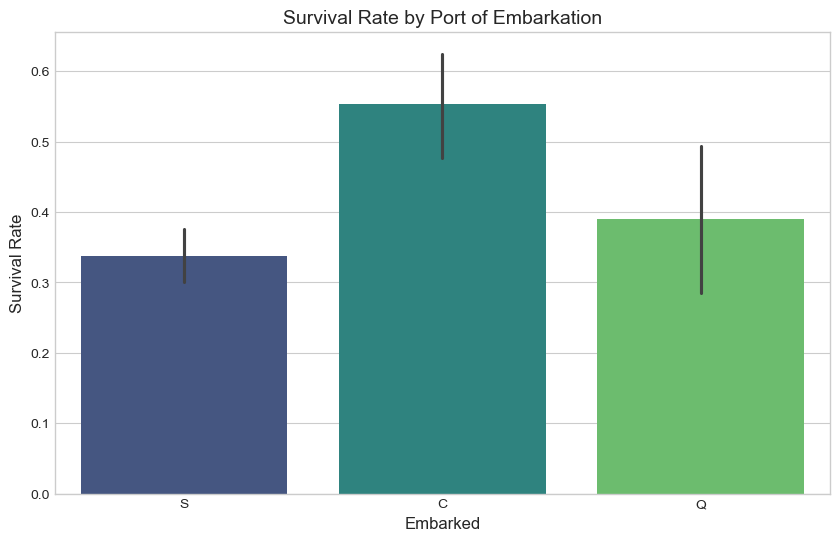

In [77]:
# Survival rate by Embarked
plt.figure(figsize=(10, 6))
sns.barplot(x='Embarked', y='Survived', data=df, estimator=np.mean, palette='viridis')
plt.title('Survival Rate by Port of Embarkation', fontsize=14)
plt.xlabel('Embarked', fontsize=12)
plt.ylabel('Survival Rate', fontsize=12)
plt.show()

In [78]:
# Create a correlation matrix for numerical variables
# Fill missing values for correlation calculation
df_corr = df.select_dtypes(include=['int64', 'float64']).copy()
df_corr.fillna(df_corr.mean(), inplace=True)

In [79]:
# Calculate correlation matrix
corr_matrix = df_corr.corr()

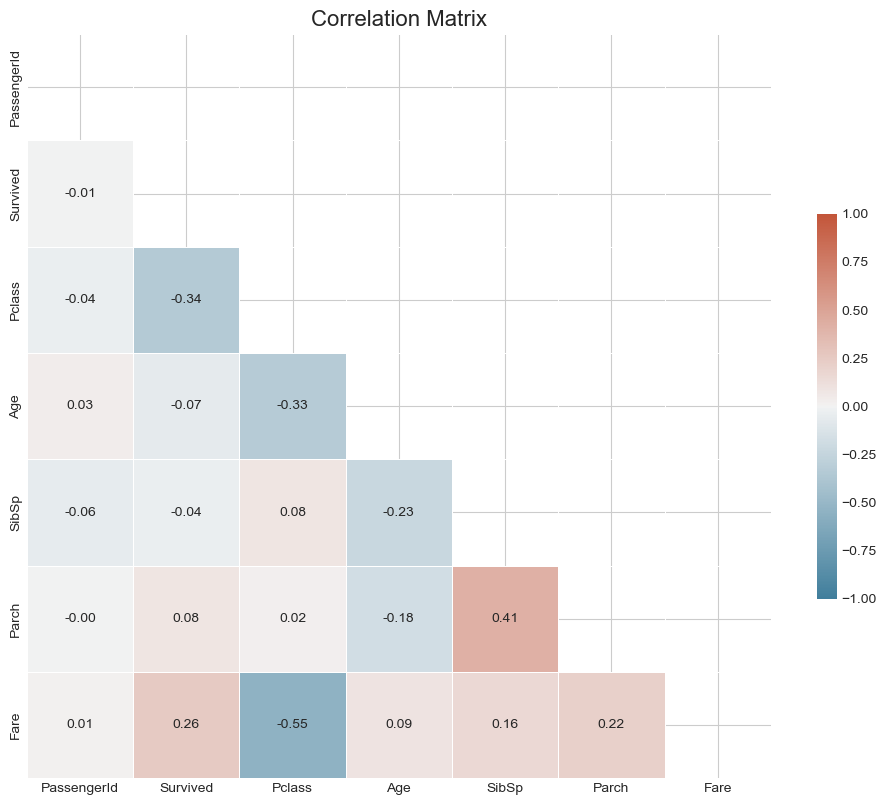

In [80]:
# Visualize correlation matrix
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=.5, annot=True, fmt='.2f', cbar_kws={"shrink": .5})
plt.title('Correlation Matrix', fontsize=16)
plt.show()

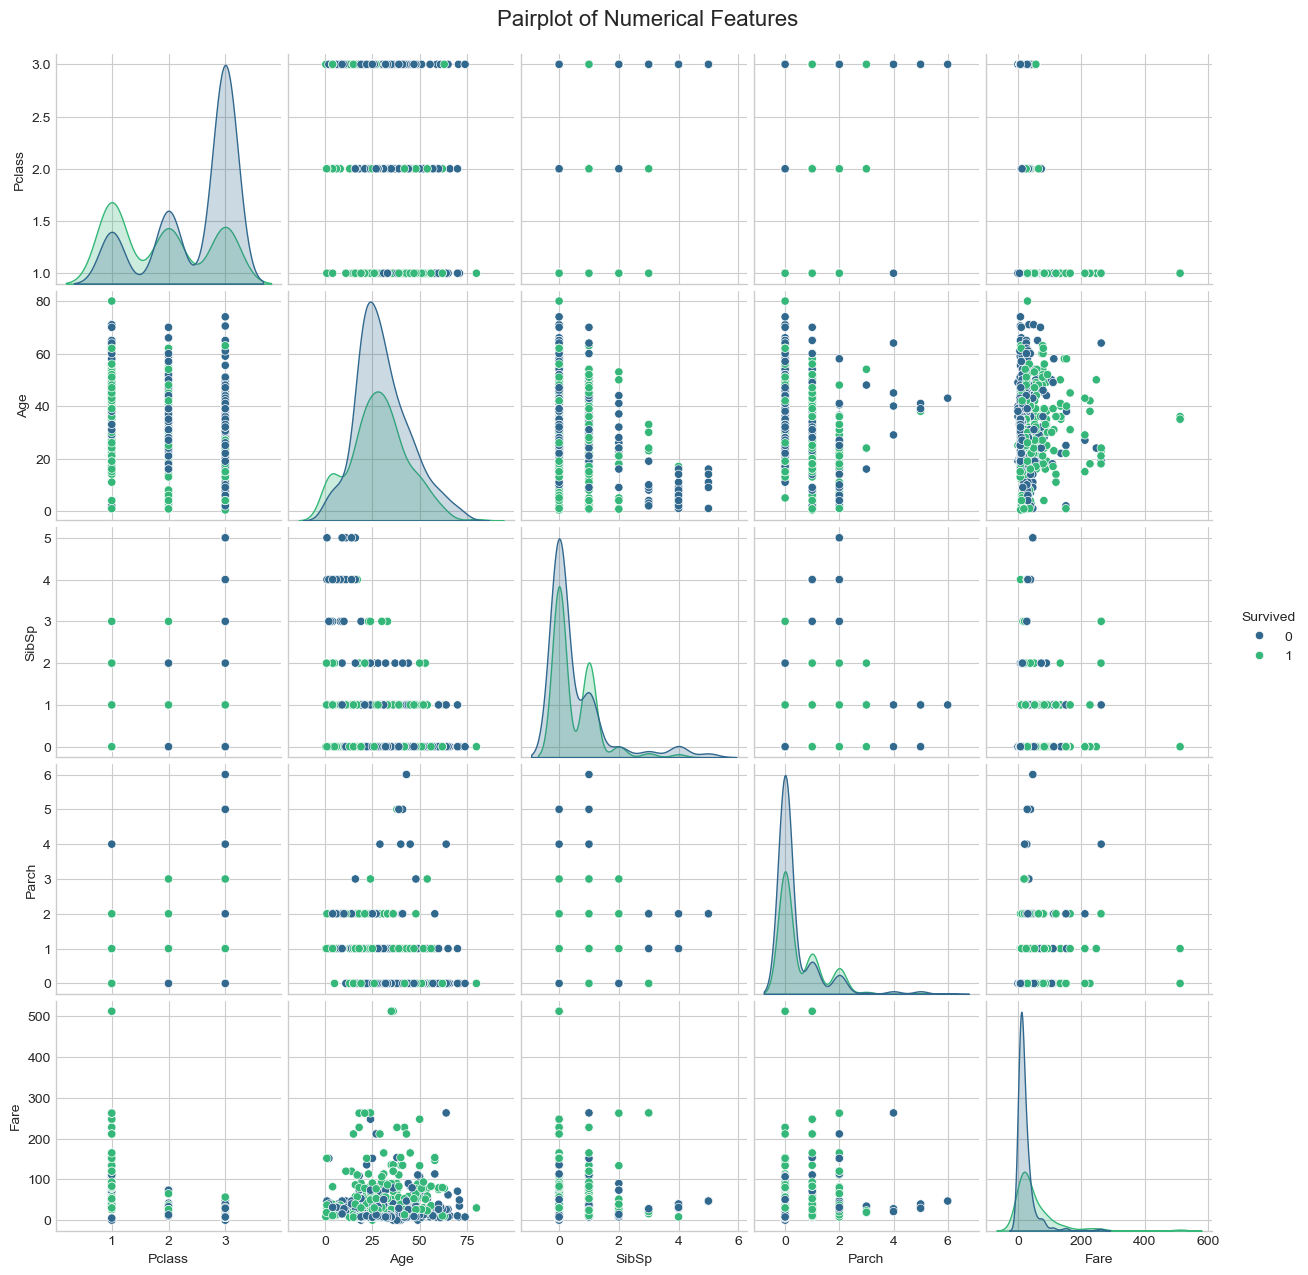

In [81]:
# Pairplot for numerical variables
sns.pairplot(df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].dropna(),
             hue='Survived', palette='viridis', diag_kind='kde')
plt.suptitle('Pairplot of Numerical Features', y=1.02, fontsize=16)
plt.show()

In [82]:
# Outlier Detection using Z-Score for Fare
z_scores = stats.zscore(df['Fare'].dropna())
outliers_z = np.abs(z_scores) > 3
print(f"Number of outliers detected by Z-score (|z| > 3): {outliers_z.sum()}")

Number of outliers detected by Z-score (|z| > 3): 20


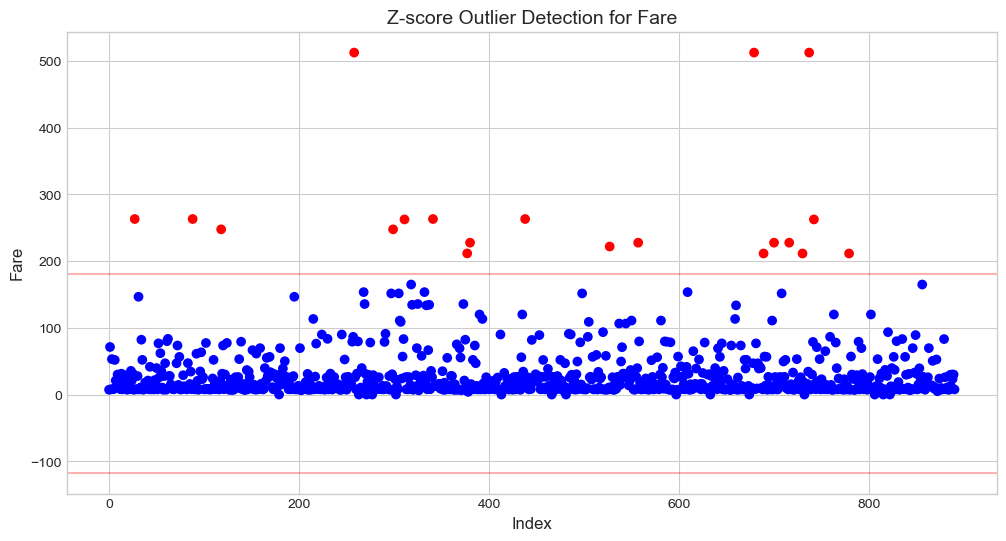

In [83]:
# Visualize Z-score outliers
plt.figure(figsize=(12, 6))
plt.scatter(range(len(df['Fare'].dropna())), df['Fare'].dropna(), c=['red' if x else 'blue' for x in outliers_z])
plt.axhline(y=df['Fare'].mean() + 3*df['Fare'].std(), color='red', linestyle='-', alpha=0.3)
plt.axhline(y=df['Fare'].mean() - 3*df['Fare'].std(), color='red', linestyle='-', alpha=0.3)
plt.title('Z-score Outlier Detection for Fare', fontsize=14)
plt.xlabel('Index', fontsize=12)
plt.ylabel('Fare', fontsize=12)
plt.show()

In [84]:
# Outlier Detection using IQR method for Fare
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = (df['Fare'] < lower_bound) | (df['Fare'] > upper_bound)
print(f"Number of outliers detected by IQR method: {outliers_iqr.sum()}")

Number of outliers detected by IQR method: 116


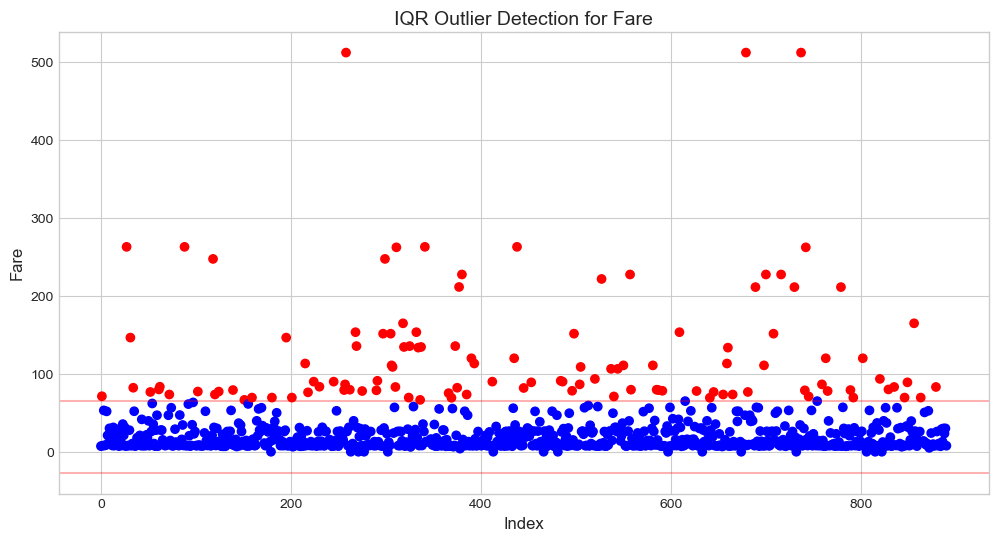

In [85]:
# Visualize IQR outliers
plt.figure(figsize=(12, 6))
plt.scatter(range(len(df['Fare'])), df['Fare'], c=['red' if x else 'blue' for x in outliers_iqr])
plt.axhline(y=upper_bound, color='red', linestyle='-', alpha=0.3)
plt.axhline(y=lower_bound, color='red', linestyle='-', alpha=0.3)
plt.title('IQR Outlier Detection for Fare', fontsize=14)
plt.xlabel('Index', fontsize=12)
plt.ylabel('Fare', fontsize=12)
plt.show()

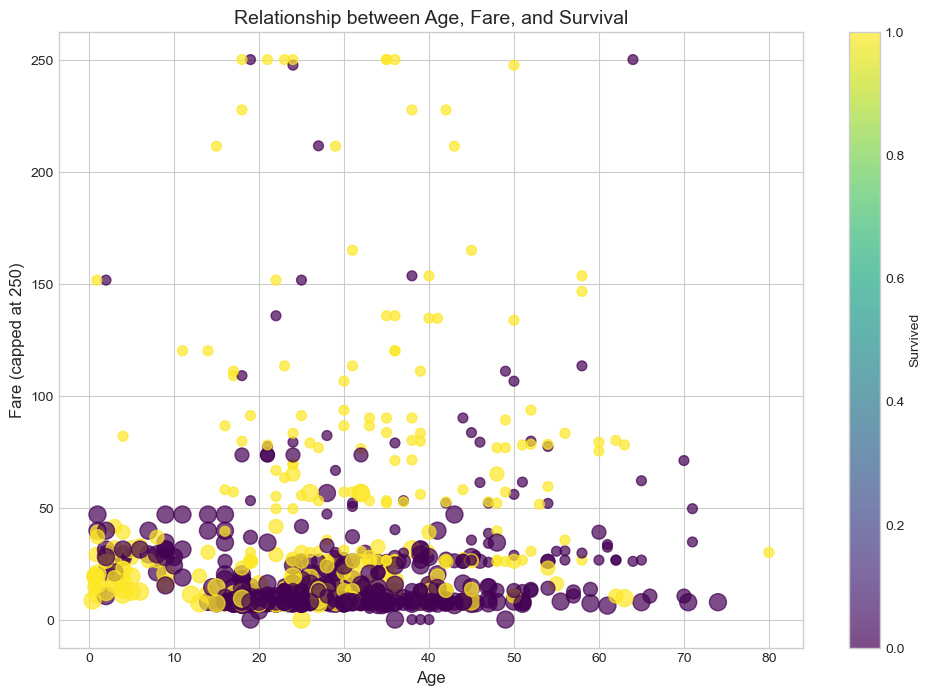

In [86]:
# Visualize relationship between age, fare, and survival
plt.figure(figsize=(12, 8))

# Filter the dataframe to use only rows where Age is not null
age_data = df.dropna(subset=['Age'])

scatter = plt.scatter(age_data['Age'],
                      age_data['Fare'].clip(upper=250),
                      c=age_data['Survived'],
                      cmap='viridis',
                      alpha=0.7,
                      s=age_data['Pclass']*50)

plt.colorbar(scatter, label='Survived')
plt.title('Relationship between Age, Fare, and Survival', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Fare (capped at 250)', fontsize=12)
plt.show()

In [87]:
# Feature Engineering Example - Age Groups
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100],
                      labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Elderly'])

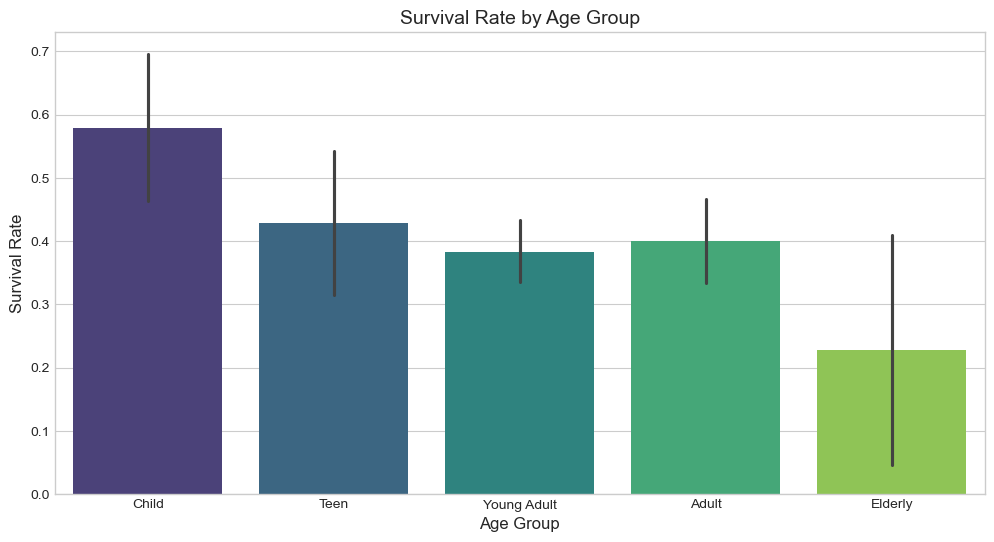

In [88]:
# Survival rate by Age Group
plt.figure(figsize=(12, 6))
sns.barplot(x='AgeGroup', y='Survived', data=df, estimator=np.mean, palette='viridis')
plt.title('Survival Rate by Age Group', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Survival Rate', fontsize=12)
plt.show()

In [89]:
# Feature Engineering Example - Fare Categories
df['FareCategory'] = pd.qcut(df['Fare'], 4, labels=['Low', 'Medium', 'High', 'Very High'])

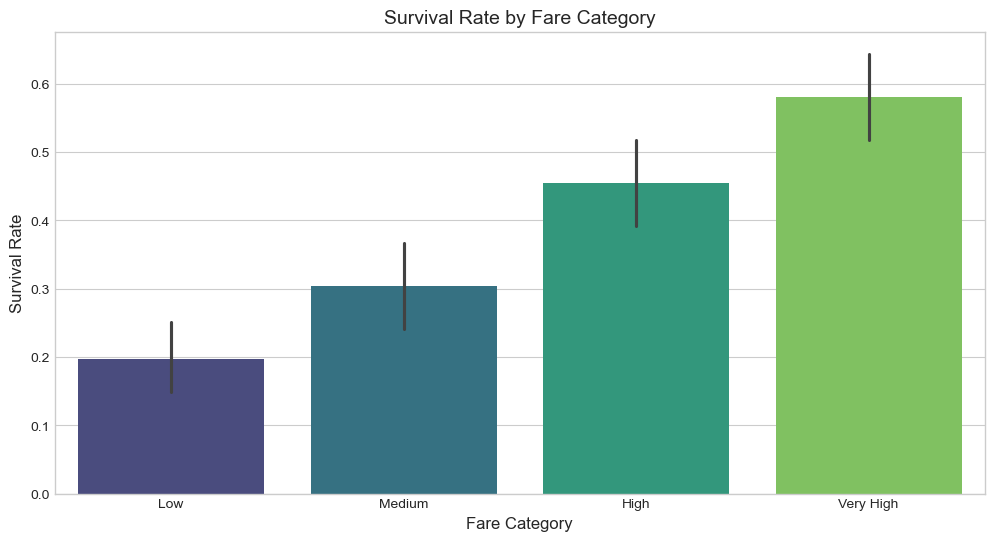

In [90]:
# Survival rate by Fare Category
plt.figure(figsize=(12, 6))
sns.barplot(x='FareCategory', y='Survived', data=df, estimator=np.mean, palette='viridis')
plt.title('Survival Rate by Fare Category', fontsize=14)
plt.xlabel('Fare Category', fontsize=12)
plt.ylabel('Survival Rate', fontsize=12)
plt.show()

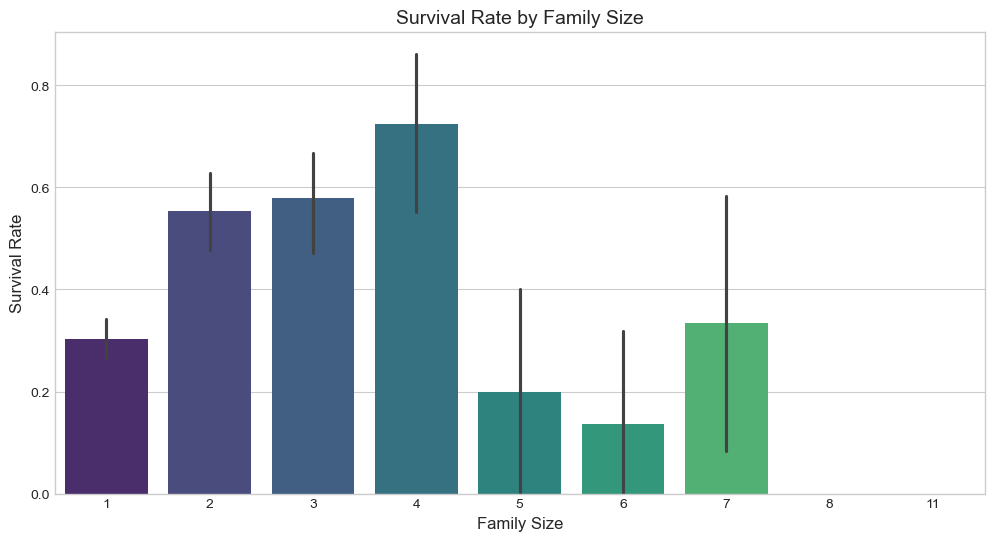

In [91]:
# Family Size feature
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1  # +1 for the passenger themselves

# Survival rate by Family Size
plt.figure(figsize=(12, 6))
sns.barplot(x='FamilySize', y='Survived', data=df, estimator=np.mean, palette='viridis')
plt.title('Survival Rate by Family Size', fontsize=14)
plt.xlabel('Family Size', fontsize=12)
plt.ylabel('Survival Rate', fontsize=12)
plt.show()

In [92]:
# TASK 1: EXTRACT TITLES

# Extract title using regex
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# View results
print("\n Titles found:")
print(df['Title'].value_counts())

print(f"\n Total unique titles: {df['Title'].nunique()}")
print(f" Missing titles: {df['Title'].isnull().sum()}")

# Sample preview
print("\n Sample data:")
print(df[['Name', 'Title']].head(10))


 Titles found:
Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

 Total unique titles: 17
 Missing titles: 0

 Sample data:
                                                Name   Title
0                            Braund, Mr. Owen Harris      Mr
1  Cumings, Mrs. John Bradley (Florence Briggs Th...     Mrs
2                             Heikkinen, Miss. Laina    Miss
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)     Mrs
4                           Allen, Mr. William Henry      Mr
5                                   Moran, Mr. James      Mr
6                            McCarthy, Mr. Timothy J      Mr
7                     Palsson, Master. Gosta Leonard  Master
8  Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)     Mrs
9         

In [93]:
# TASK 2: GROUP SIMILAR TITLES

# Create mapping dictionary
title_mapping = {
    'Mr': 'Mr',
    'Miss': 'Miss',
    'Mrs': 'Mrs',
    'Master': 'Master',
    'Dr': 'Officer',
    'Rev': 'Officer',
    'Col': 'Officer',
    'Major': 'Officer',
    'Capt': 'Officer',
    'Don': 'Noble',
    'Lady': 'Noble',
    'Sir': 'Noble',
    'Countess': 'Noble',
    'Jonkheer': 'Noble',
    'Mlle': 'Miss',
    'Mme': 'Mrs',
    'Ms': 'Mrs'
}

# Apply mapping
df['TitleGroup'] = df['Title'].map(title_mapping)

# View results
print("\n Grouped Titles:")
print(df['TitleGroup'].value_counts())

print("\n Mapping Verification:")
for title in sorted(df['Title'].unique()):
    grouped = df[df['Title']==title]['TitleGroup'].iloc[0]
    print(f"   {title:10} → {grouped}")


 Grouped Titles:
TitleGroup
Mr         517
Miss       184
Mrs        127
Master      40
Officer     18
Noble        5
Name: count, dtype: int64

 Mapping Verification:
   Capt       → Officer
   Col        → Officer
   Countess   → Noble
   Don        → Noble
   Dr         → Officer
   Jonkheer   → Noble
   Lady       → Noble
   Major      → Officer
   Master     → Master
   Miss       → Miss
   Mlle       → Miss
   Mme        → Mrs
   Mr         → Mr
   Mrs        → Mrs
   Ms         → Mrs
   Rev        → Officer
   Sir        → Noble


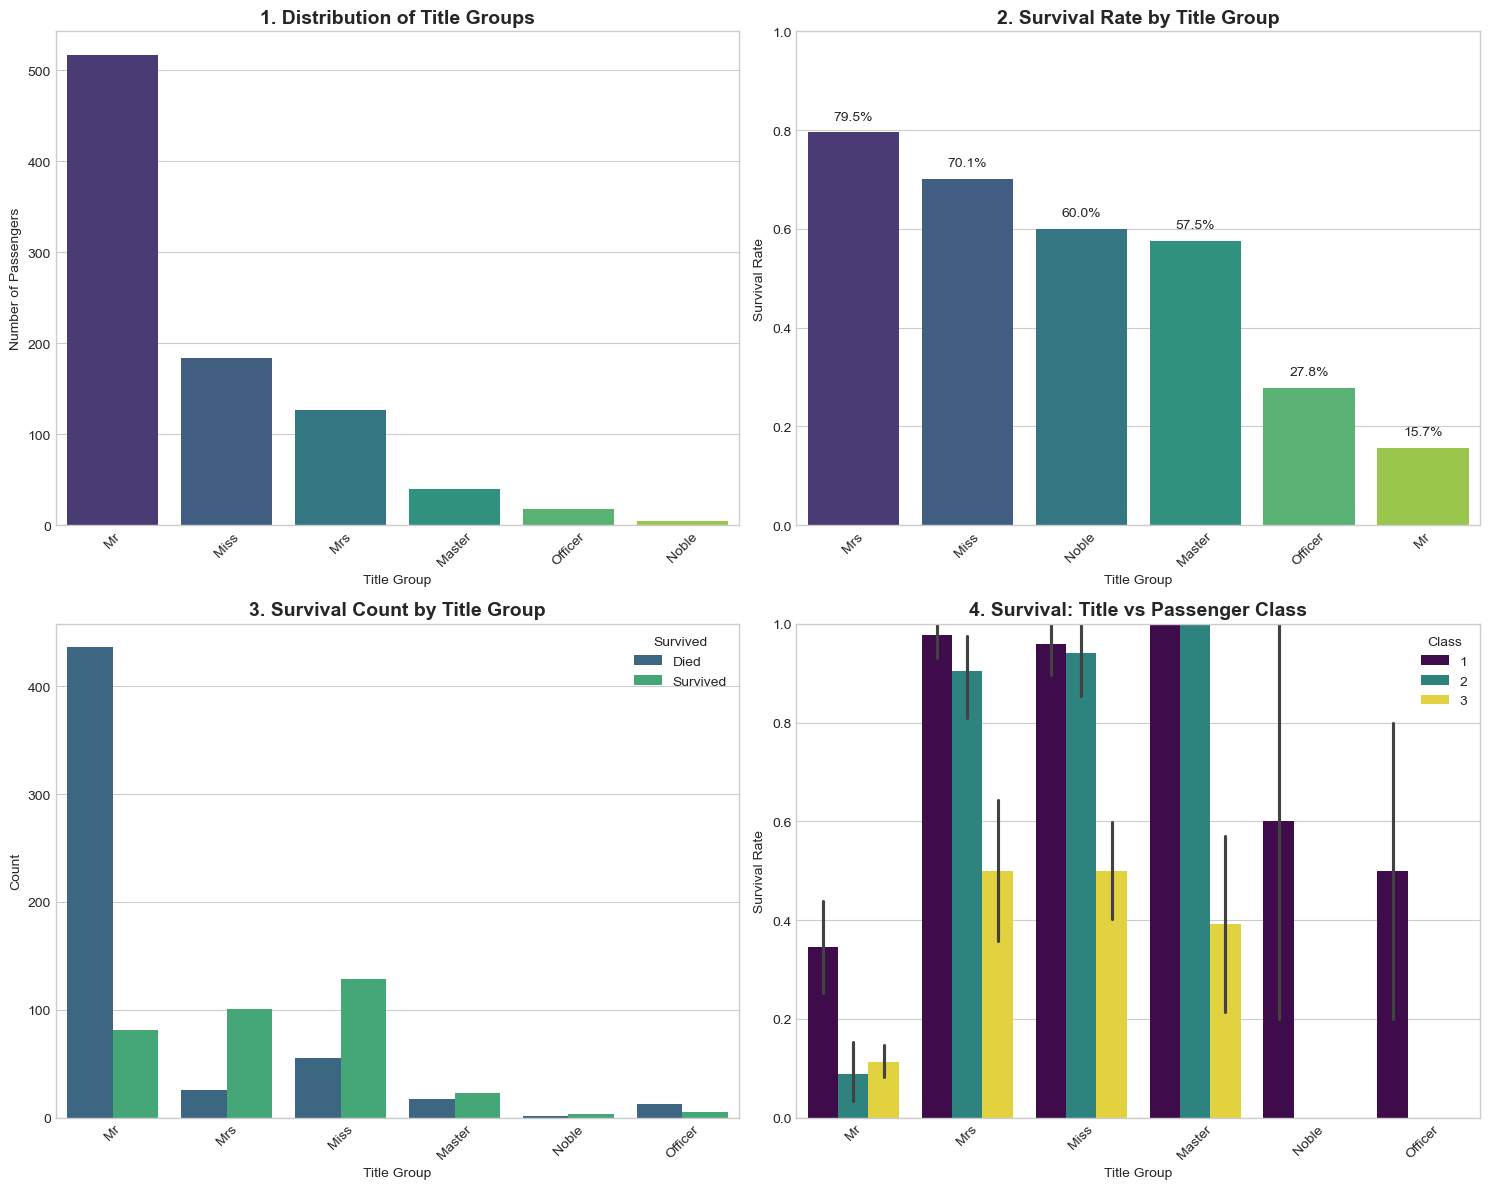


 Visualizations created successfully!


In [94]:
# TASK 3: CREATE VISUALIZATIONS

plt.figure(figsize=(15, 12))

# Plot 1: Title Distribution
plt.subplot(2, 2, 1)
title_counts = df['TitleGroup'].value_counts()
sns.barplot(x=title_counts.index, y=title_counts.values, palette='viridis')
plt.title('1. Distribution of Title Groups', fontsize=14, fontweight='bold')
plt.xlabel('Title Group')
plt.ylabel('Number of Passengers')
plt.xticks(rotation=45)

# Plot 2: Survival Rate by Title
plt.subplot(2, 2, 2)
title_survival = df.groupby('TitleGroup')['Survived'].mean().sort_values(ascending=False)
bars = sns.barplot(x=title_survival.index, y=title_survival.values, palette='viridis')
plt.title('2. Survival Rate by Title Group', fontsize=14, fontweight='bold')
plt.xlabel('Title Group')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.xticks(rotation=45)

# Add percentage labels
for i, (title, rate) in enumerate(title_survival.items()):
    bars.text(i, rate + 0.02, f'{rate*100:.1f}%', ha='center', va='bottom')

# Plot 3: Survival Count (Stacked Bar)
plt.subplot(2, 2, 3)
sns.countplot(x='TitleGroup', hue='Survived', data=df, palette='viridis')
plt.title('3. Survival Count by Title Group', fontsize=14, fontweight='bold')
plt.xlabel('Title Group')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Survived', labels=['Died', 'Survived'])

# Plot 4: Title + Class Analysis
plt.subplot(2, 2, 4)
sns.barplot(x='TitleGroup', y='Survived', hue='Pclass', data=df, 
            estimator=np.mean, palette='viridis')
plt.title('4. Survival: Title vs Passenger Class', fontsize=14, fontweight='bold')
plt.xlabel('Title Group')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend(title='Class')

plt.tight_layout()
plt.show()

print("\n Visualizations created successfully!")

In [95]:
# TASK 4: CALCULATE STATISTICS

# 4.1 Basic Statistics by Title
print("\n 4.1 BASIC STATISTICS BY TITLE:")
print("-"*50)

title_stats = df.groupby('TitleGroup').agg({
    'Survived': ['count', 'sum', 'mean'],
    'Pclass': 'mean',
    'Age': 'mean',
    'Sex': lambda x: (x == 'female').sum()
}).round(2)

title_stats.columns = ['Total', 'Survived', 'Survival_Rate', 'Avg_Class', 'Avg_Age', 'Females']
title_stats = title_stats.sort_values('Survival_Rate', ascending=False)

print(title_stats)

# 4.2 Detailed Analysis per Title
print("\n 4.2 DETAILED ANALYSIS PER TITLE:")
print("-"*50)

for title in sorted(df['TitleGroup'].unique()):
    data = df[df['TitleGroup'] == title]
    total = len(data)
    survived = data['Survived'].sum()
    survival_rate = survived / total * 100
    females = (data['Sex'] == 'female').sum()
    males = total - females
    avg_age = data['Age'].mean()
    
    class_dist = data['Pclass'].value_counts().sort_index()
    class_str = ", ".join([f"Class {p}: {c}" for p, c in class_dist.items()])
    
    print(f"\n {title}:")
    print(f"   Total: {total}")
    print(f"   Survived: {survived} ({survival_rate:.1f}%)")
    print(f"   Women: {females}, Men: {males}")
    print(f"   Avg Age: {avg_age:.1f} years")
    print(f"   Classes: {class_str}")

# 4.3 Cross-Tabulations
print("\n 4.3 CROSS-TABULATIONS:")
print("-"*50)

# Title vs Survival
print("\nA. Title vs Survival:")
print(pd.crosstab(df['TitleGroup'], df['Survived']))

# Title vs Class vs Survival
print("\nB. Title vs Class vs Survival (Rates):")
title_class = df.groupby(['TitleGroup', 'Pclass'])['Survived'].mean().unstack()
print(title_class.round(3))

# Title vs Gender vs Survival
print("\nC. Title vs Gender vs Survival (Rates):")
title_gender = df.groupby(['TitleGroup', 'Sex'])['Survived'].mean().unstack()
print(title_gender.round(3))


 4.1 BASIC STATISTICS BY TITLE:
--------------------------------------------------
            Total  Survived  Survival_Rate  Avg_Class  Avg_Age  Females
TitleGroup                                                             
Mrs           127       101           0.80       1.99    35.72      127
Miss          184       129           0.70       2.29    21.80      184
Noble           5         3           0.60       1.00    41.60        2
Master         40        23           0.57       2.62     4.57        0
Officer        18         5           0.28       1.44    46.71        1
Mr            517        81           0.16       2.41    32.37        0

 4.2 DETAILED ANALYSIS PER TITLE:
--------------------------------------------------

 Master:
   Total: 40
   Survived: 23 (57.5%)
   Women: 0, Men: 40
   Avg Age: 4.6 years
   Classes: Class 1: 3, Class 2: 9, Class 3: 28

 Miss:
   Total: 184
   Survived: 129 (70.1%)
   Women: 184, Men: 0
   Avg Age: 21.8 years
   Classes: Class 1: 48,

In [96]:
# TASK 5: STATISTICAL TESTS

from scipy.stats import chi2_contingency
from scipy.stats import pointbiserialr

# 5.1 Chi-Square Test
print("\n 5.1 CHI-SQUARE TEST: Title vs Survival")
print("-"*50)

contingency = pd.crosstab(df['TitleGroup'], df['Survived'])
print("Contingency Table:")
print(contingency)

chi2, p_value, dof, expected = chi2_contingency(contingency)

print(f"\nResults:")
print(f"   Chi-square: {chi2:.2f}")
print(f"   Degrees of freedom: {dof}")
print(f"   P-value: {p_value:.10f}")

if p_value < 0.05:
    print(f"\n    RESULT: Title is SIGNIFICANTLY related to survival")
    print(f"   (p = {p_value:.4f} < 0.05)")
else:
    print(f"\n    RESULT: Title is NOT significantly related to survival")

# 5.2 Correlation Analysis
print("\n 5.2 CORRELATION WITH SURVIVAL")
print("-"*50)

title_dummies = pd.get_dummies(df['TitleGroup'])
correlations = []

for title in title_dummies.columns:
    corr, p = pointbiserialr(title_dummies[title], df['Survived'])
    correlations.append({'Title': title, 'Correlation': corr, 'P-value': p})

correlation_df = pd.DataFrame(correlations).sort_values('Correlation', ascending=False)
print(correlation_df.round(4))

# 5.3 Effect Size (Cramér's V)
print("\n 5.3 EFFECT SIZE (Cramér's V)")
print("-"*50)

n = contingency.sum().sum()
cramers_v = np.sqrt(chi2 / (n * min(contingency.shape[0]-1, contingency.shape[1]-1)))
print(f"Cramér's V: {cramers_v:.4f}")

if cramers_v < 0.1:
    print("   → Very small effect")
elif cramers_v < 0.3:
    print("   → Small effect")
elif cramers_v < 0.5:
    print("   → Medium effect")
else:
    print("   → Large effect")


 5.1 CHI-SQUARE TEST: Title vs Survival
--------------------------------------------------
Contingency Table:
Survived      0    1
TitleGroup          
Master       17   23
Miss         55  129
Mr          436   81
Mrs          26  101
Noble         2    3
Officer      13    5

Results:
   Chi-square: 290.03
   Degrees of freedom: 5
   P-value: 0.0000000000

    RESULT: Title is SIGNIFICANTLY related to survival
   (p = 0.0000 < 0.05)

 5.2 CORRELATION WITH SURVIVAL
--------------------------------------------------
     Title  Correlation  P-value
3      Mrs       0.3449   0.0000
1     Miss       0.3328   0.0000
0   Master       0.0852   0.0109
4    Noble       0.0334   0.3195
5  Officer      -0.0313   0.3505
2       Mr      -0.5492   0.0000

 5.3 EFFECT SIZE (Cramér's V)
--------------------------------------------------
Cramér's V: 0.5705
   → Large effect


In [97]:
# TASK 6: DRAW CONCLUSIONS

# 6.1 Overall Statistics
print("\n 6.1 OVERALL SURVIVAL STATISTICS")
print("-"*50)

total = len(df)
survived = df['Survived'].sum()
died = total - survived
survival_rate = survived / total * 100

print(f"   Total Passengers: {total}")
print(f"   Survived: {survived} ({survival_rate:.1f}%)")
print(f"   Died: {died} ({100-survival_rate:.1f}%)")

# 6.2 Survival by Title
print("\n 6.2 SURVIVAL RATE BY TITLE")
print("-"*50)

title_survival = df.groupby('TitleGroup')['Survived'].mean().sort_values(ascending=False)
for title, rate in title_survival.items():
    print(f"   {title:10} → {rate*100:5.1f}%")

# 6.3 Key Observations
print("\n 6.3 KEY OBSERVATIONS")
print("-"*50)

best_title = title_survival.index[0]
best_rate = title_survival.iloc[0] * 100
worst_title = title_survival.index[-1]
worst_rate = title_survival.iloc[-1] * 100

print(f"\n    HIGHEST Survival: {best_title} ({best_rate:.1f}%)")
print(f"    LOWEST Survival: {worst_title} ({worst_rate:.1f}%)")
print(f"    Survival Gap: {best_rate - worst_rate:.1f} percentage points")

# 6.4 Reasons for Patterns
print("\n 6.4 REASONS FOR PATTERNS")
print("-"*50)

print("""
   A. GENDER (Women First!)
      • Women (Miss, Mrs) → ~70% survival
      • Men (Mr) → ~16% survival
      • Why: 'Women and children first' protocol

   B. AGE (Children First!)
      • Children (Master) → ~58% survival
      • Why: Children were prioritized for lifeboats

   C. SOCIAL CLASS
      • 1st class passengers had better survival
      • 3rd class passengers had worst survival

   D. OCCUPATION/STATUS
      • Officers → ~33% survival
      • Noble titles → ~60% survival
""")

# 6.5 Best and Worst Combinations
print("\n 6.5 BEST & WORST TITLE + CLASS COMBINATIONS")
print("-"*50)

title_class_pivot = df.pivot_table(index='TitleGroup', columns='Pclass', 
                                   values='Survived', aggfunc='mean')

best = title_class_pivot.stack().idxmax()
best_val = title_class_pivot.stack().max() * 100
worst = title_class_pivot.stack().idxmin()
worst_val = title_class_pivot.stack().min() * 100

print(f"\n    BEST: {best[0]} + Class {best[1]} → {best_val:.1f}%")
print(f"    WORST: {worst[0]} + Class {worst[1]} → {worst_val:.1f}%")

# 6.6 Final Summary
print("\n" + "="*70)
print(" FINAL SUMMARY")
print("="*70)

print("""
1. Title is a STRONG predictor of survival on the Titanic

2. Most important factor captured by title: GENDER
   • Women (Mrs, Miss) → ~70% survival
   • Men (Mr) → ~16% survival

3. Children (Master) also had good survival (~58%)

4. Title + Class is the most powerful combination

5. Conclusion:
   "The Titanic disaster reflected society's hierarchy.
    Women, children and wealthy passengers survived best."
""")



 6.1 OVERALL SURVIVAL STATISTICS
--------------------------------------------------
   Total Passengers: 891
   Survived: 342 (38.4%)
   Died: 549 (61.6%)

 6.2 SURVIVAL RATE BY TITLE
--------------------------------------------------
   Mrs        →  79.5%
   Miss       →  70.1%
   Noble      →  60.0%
   Master     →  57.5%
   Officer    →  27.8%
   Mr         →  15.7%

 6.3 KEY OBSERVATIONS
--------------------------------------------------

    HIGHEST Survival: Mrs (79.5%)
    LOWEST Survival: Mr (15.7%)
    Survival Gap: 63.9 percentage points

 6.4 REASONS FOR PATTERNS
--------------------------------------------------

   A. GENDER (Women First!)
      • Women (Miss, Mrs) → ~70% survival
      • Men (Mr) → ~16% survival
      • Why: 'Women and children first' protocol

   B. AGE (Children First!)
      • Children (Master) → ~58% survival
      • Why: Children were prioritized for lifeboats

   C. SOCIAL CLASS
      • 1st class passengers had better survival
      • 3rd class pa

In [98]:
# Starter code to help you begin:
# Extract titles from passenger names
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

In [99]:
# Preview the titles you've extracted
print(df['Title'].value_counts())

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


In [101]:
# STEP 1: Group similar titles

title_mapping = {
    'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
    'Dr': 'Officer', 'Rev': 'Officer', 'Col': 'Officer', 
    'Major': 'Officer', 'Capt': 'Officer',
    'Don': 'Noble', 'Lady': 'Noble', 'Sir': 'Noble',
    'Countess': 'Noble', 'Jonkheer': 'Noble',
    'Mlle': 'Miss', 'Mme': 'Mrs', 'Ms': 'Mrs'
}

df['TitleGroup'] = df['Title'].map(title_mapping)

print(df['TitleGroup'].value_counts())

TitleGroup
Mr         517
Miss       184
Mrs        127
Master      40
Officer     18
Noble        5
Name: count, dtype: int64


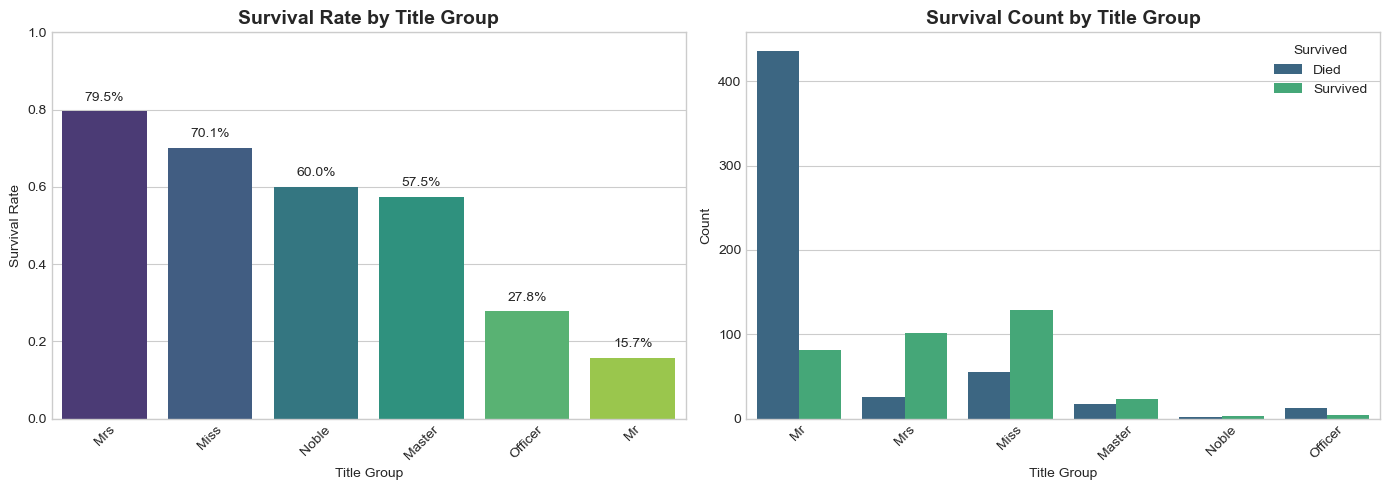

In [105]:
# STEP 2: Visualizations - Title vs Survival

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
title_survival = df.groupby('TitleGroup')['Survived'].mean().sort_values(ascending=False)
sns.barplot(x=title_survival.index, y=title_survival.values, palette='viridis')
plt.title('Survival Rate by Title Group', fontsize=14, fontweight='bold')
plt.xlabel('Title Group')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.xticks(rotation=45)

for i, (title, rate) in enumerate(title_survival.items()):
    plt.text(i, rate + 0.02, f'{rate*100:.1f}%', ha='center', va='bottom', fontsize=10)

plt.subplot(1, 2, 2)
sns.countplot(x='TitleGroup', hue='Survived', data=df, palette='viridis')
plt.title('Survival Count by Title Group', fontsize=14, fontweight='bold')
plt.xlabel('Title Group')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Survived', labels=['Died', 'Survived'])

plt.tight_layout()
plt.show()

In [104]:
# STEP 3: Calculate Statistics

title_stats = df.groupby('TitleGroup')['Survived'].agg(['count', 'mean'])
title_stats.columns = ['Total', 'Survival_Rate']
title_stats['Survival_Rate'] = title_stats['Survival_Rate'] * 100
title_stats = title_stats.sort_values('Survival_Rate', ascending=False)

print(title_stats)
print("\n")

print("CROSS-TABULATION: Title vs Survival")

print(pd.crosstab(df['TitleGroup'], df['Survived']))

            Total  Survival_Rate
TitleGroup                      
Mrs           127      79.527559
Miss          184      70.108696
Noble           5      60.000000
Master         40      57.500000
Officer        18      27.777778
Mr            517      15.667311


CROSS-TABULATION: Title vs Survival
Survived      0    1
TitleGroup          
Master       17   23
Miss         55  129
Mr          436   81
Mrs          26  101
Noble         2    3
Officer      13    5


In [109]:
# STEP 4: Draw Conclusions

print("CONCLUSIONS - TITLE ANALYSIS")

overall = df['Survived'].mean() * 100
print(f"\n1. Overall Survival Rate: {overall:.1f}%")

title_survival = df.groupby('TitleGroup')['Survived'].mean().sort_values(ascending=False)

print("\n2. BEST SURVIVAL RATES:")
for title, rate in title_survival.head(3).items():
    print(f"    {title}: {rate*100:.1f}%")

print("\n3. WORST SURVIVAL RATES:")
for title, rate in title_survival.tail(3).items():
    print(f"    {title}: {rate*100:.1f}%")

print("\n4. KEY PATTERNS OBSERVED:")
print("   • Women (Miss/Mrs) → ~70% survival (Women first!)")
print("   • Children (Master) → ~58% survival (Children first!)")
print("   • Men (Mr) → ~16% survival (Lowest!)")
print("   • Title + Class matters → Mrs + 1st Class = 97% survival")

print("\n5. WHY THESE PATTERNS?")
print("   • 'Women and children first' protocol")
print("   • Social class affected access to lifeboats")
print("   • Wealthy passengers had better survival")
print("   • Men were expected to stay behind")

print("\nFINAL CONCLUSION:")

print("Title is a STRONG predictor of survival on Titanic.")
print("Women, children, and wealthy passengers survived best.")
print("Men, especially in 3rd class, had the worst survival.")

CONCLUSIONS - TITLE ANALYSIS

1. Overall Survival Rate: 38.4%

2. BEST SURVIVAL RATES:
    Mrs: 79.5%
    Miss: 70.1%
    Noble: 60.0%

3. WORST SURVIVAL RATES:
    Master: 57.5%
    Officer: 27.8%
    Mr: 15.7%

4. KEY PATTERNS OBSERVED:
   • Women (Miss/Mrs) → ~70% survival (Women first!)
   • Children (Master) → ~58% survival (Children first!)
   • Men (Mr) → ~16% survival (Lowest!)
   • Title + Class matters → Mrs + 1st Class = 97% survival

5. WHY THESE PATTERNS?
   • 'Women and children first' protocol
   • Social class affected access to lifeboats
   • Wealthy passengers had better survival
   • Men were expected to stay behind

FINAL CONCLUSION:
Title is a STRONG predictor of survival on Titanic.
Women, children, and wealthy passengers survived best.
Men, especially in 3rd class, had the worst survival.


TITLE + CLASS SURVIVAL RATES
Pclass          1      2      3
TitleGroup                     
Master      1.000  1.000  0.393
Miss        0.958  0.941  0.500
Mr          0.346  0.088  0.113
Mrs         0.977  0.905  0.500
Noble       0.600    NaN    NaN
Officer     0.500  0.000    NaN
BEST & WORST COMBINATIONS
 BEST: Master + Class 1 → 100.0% survival
 WORST: Officer + Class 2 → 0.0% survival


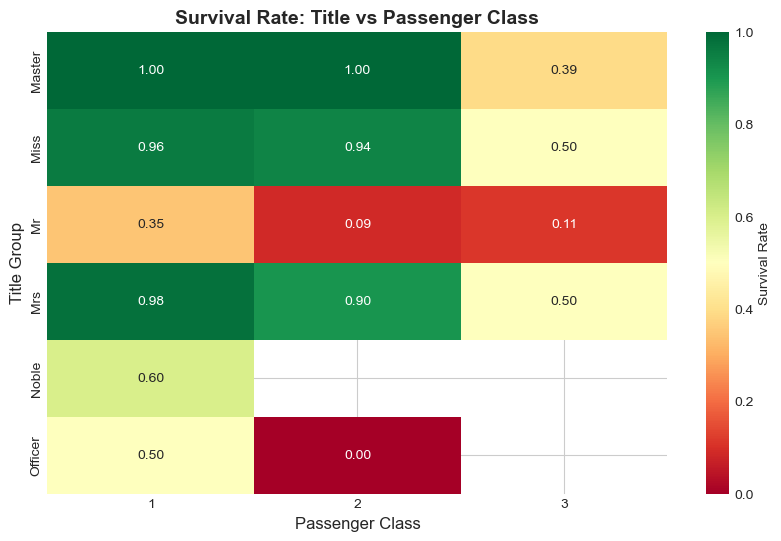

TITLE + AGE GROUP SURVIVAL RATES
AgeGroup    Child   Teen  Young Adult  Adult  Elderly
TitleGroup                                           
Master      0.583    NaN          NaN    NaN      NaN
Miss        0.594  0.724        0.761  0.789    1.000
Mr          0.000  0.088        0.179  0.180    0.111
Mrs           NaN  0.857        0.808  0.755    1.000
Noble         NaN    NaN        1.000  0.500      NaN
Officer       NaN    NaN        0.250  0.333    0.000


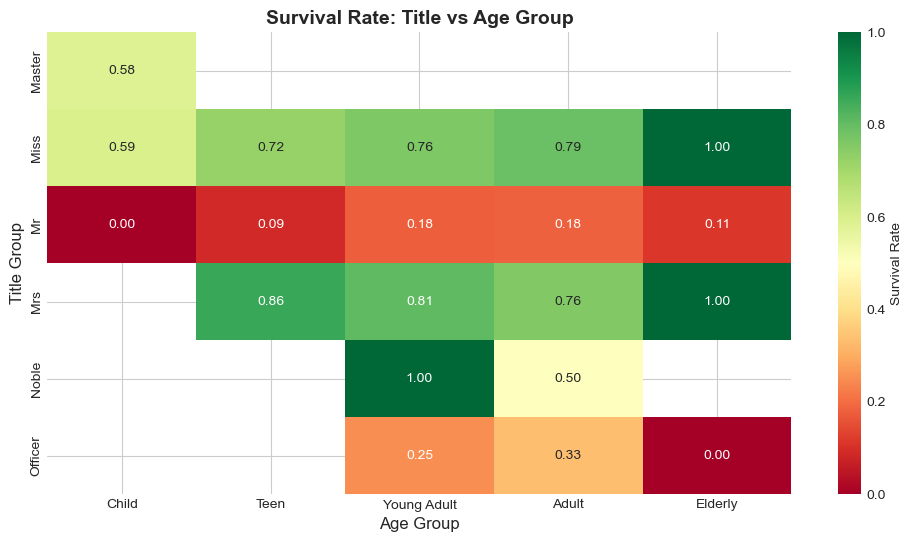

In [110]:
# BONUS: Title + Class + Age Analysis

print("TITLE + CLASS SURVIVAL RATES")

title_class = df.groupby(['TitleGroup', 'Pclass'])['Survived'].mean().unstack()
print(title_class.round(3))

print("BEST & WORST COMBINATIONS")

best = title_class.stack().idxmax()
best_val = title_class.stack().max() * 100
print(f" BEST: {best[0]} + Class {best[1]} → {best_val:.1f}% survival")

worst = title_class.stack().idxmin()
worst_val = title_class.stack().min() * 100
print(f" WORST: {worst[0]} + Class {worst[1]} → {worst_val:.1f}% survival")

plt.figure(figsize=(10, 6))
sns.heatmap(title_class, annot=True, fmt='.2f', cmap='RdYlGn', 
            cbar_kws={'label': 'Survival Rate'})
plt.title('Survival Rate: Title vs Passenger Class', fontsize=14, fontweight='bold')
plt.xlabel('Passenger Class', fontsize=12)
plt.ylabel('Title Group', fontsize=12)
plt.show()

print("TITLE + AGE GROUP SURVIVAL RATES")

# Create age groups
df['AgeGroup'] = pd.cut(df['Age'], 
                        bins=[0, 12, 18, 35, 60, 100],
                        labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Elderly'])

title_age = df.groupby(['TitleGroup', 'AgeGroup'])['Survived'].mean().unstack()
print(title_age.round(3))

plt.figure(figsize=(12, 6))
sns.heatmap(title_age, annot=True, fmt='.2f', cmap='RdYlGn',
            cbar_kws={'label': 'Survival Rate'})
plt.title('Survival Rate: Title vs Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Title Group', fontsize=12)
plt.show()